In [ ]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
    print(f'Changed CWD to: {os.getcwd()}')


In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'seqeval'], check=True)
print('Dependencies ready.')

---
# Notebook 05 — BiLSTM for Disease NER

So far in this project:
- **Rule-Based NER** (F1 = 0.5771): hand-crafted regex patterns
- **CRF NER** (F1 = 0.7825): hand-engineered features + sequence modelling

Now we go **neural**: a **Bidirectional LSTM** that learns features from raw token embeddings (the Word2Vec vectors we trained in Notebook 04).

No hand-crafted features. No regex. The model reads the sentence, left-to-right and right-to-left, and learns what patterns predict `B-Disease` or `I-Disease`.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

LABEL_MAP = {0: 'O', 1: 'B-Disease', 2: 'I-Disease'}
PAD_IDX   = 0
UNK_IDX   = 1
PAD_LABEL = -100
MAX_LENGTH = 128

---
## Step 1 — Load NCBI Disease Dataset

In [ ]:
PARQUET_BASE = 'hf://datasets/ncbi_disease@refs/convert/parquet/ncbi_disease'

df_train = pd.read_parquet(f'{PARQUET_BASE}/train/0000.parquet')
df_val   = pd.read_parquet(f'{PARQUET_BASE}/validation/0000.parquet')
df_test  = pd.read_parquet(f'{PARQUET_BASE}/test/0000.parquet')

print(f'Train : {len(df_train)} sentences')
print(f'Val   : {len(df_val)}   sentences')
print(f'Test  : {len(df_test)}  sentences')
print(f'\nSample tokens : {list(df_train.iloc[0]["tokens"])[:8]}')
print(f'Sample labels : {list(df_train.iloc[0]["ner_tags"])[:8]}')

---
## Step 2 — Load Pre-trained Embeddings

In [ ]:
# Load word → index mapping
with open('models/word2idx.json') as f:
    word2idx = json.load(f)

# Load embedding matrix: shape (vocab_size, 200)
embedding_matrix = np.load('models/embedding_matrix.npy')

vocab_size, embedding_dim = embedding_matrix.shape
print(f'Vocabulary size : {vocab_size:,}')
print(f'Embedding dim   : {embedding_dim}')
print(f'Matrix shape    : {embedding_matrix.shape}')
print(f'Sample entries  : {list(word2idx.items())[:5]}')

---
## What Is an LSTM? (And Why Do We Need It?)

### The problem with plain RNNs

A plain Recurrent Neural Network (RNN) processes a sentence one word at a time. At each step $t$ it combines the current word's embedding with the previous hidden state:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

The issue: gradients **vanish** as they flow backwards through many time steps. The network forgets early context — it can't connect "patient" (token 1) with "disease" (token 20).

---

### LSTM: Long Short-Term Memory

An LSTM introduces a **cell state** $C_t$ — a "conveyor belt" that can carry information across many steps with minimal modification. Three learnable **gates** control what flows in and out:

| Gate | Formula | Purpose |
|---|---|---|
| **Forget gate** $f_t$ | $\sigma(W_f [h_{t-1}, x_t] + b_f)$ | What fraction of old memory to erase |
| **Input gate** $i_t$ | $\sigma(W_i [h_{t-1}, x_t] + b_i)$ | What new information to write |
| **Output gate** $o_t$ | $\sigma(W_o [h_{t-1}, x_t] + b_o)$ | What part of memory to expose as output |

The cell state update:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
$$h_t = o_t \odot \tanh(C_t)$$

$\sigma$ is the sigmoid function (output in [0, 1] — acts like a valve). $\odot$ is element-wise multiplication.

**Intuition for NER**: When the model sees "breast" in a biomedical context, the forget gate might preserve the disease-entity context. When it then reads "cancer", the input gate writes the B-Disease/I-Disease signal strongly. The output gate decides how much of that disease signal to pass to the classifier.

---

### Why Bidirectional?

A left-to-right LSTM only sees context *before* each token. For NER, future context also matters:

> "T-cell **leukaemia** is rare" → knowing "is rare" after "leukaemia" helps confirm it's a disease entity.

A **BiLSTM** runs two LSTMs in parallel:
- **Forward LSTM**: reads left → right, produces $\overrightarrow{h}_t$
- **Backward LSTM**: reads right → left, produces $\overleftarrow{h}_t$

At each position $t$, the two hidden states are concatenated: $h_t = [\overrightarrow{h}_t; \overleftarrow{h}_t]$

With `hidden_size=256` and `bidirectional=True`, each output vector is $256 \times 2 = 512$ dimensions — encoding both past and future context for every word.

---
## Step 3 — Data Preparation

PyTorch needs fixed-size tensors in each batch, so we:
1. **Convert tokens → indices** using `word2idx` (unknown words → index 1 = `<UNK>`)
2. **Truncate** sequences longer than `MAX_LENGTH=128`
3. **Pad** shorter sequences with `PAD_IDX=0`
4. **Pad labels** with `-100` — `CrossEntropyLoss(ignore_index=-100)` ignores these positions

In [ ]:
def tokens_to_indices(tokens, word2idx, max_length=MAX_LENGTH):
    """Convert a list of tokens to a padded index list of length max_length."""
    indices = [word2idx.get(tok, UNK_IDX) for tok in tokens[:max_length]]
    pad_len  = max_length - len(indices)
    return indices + [PAD_IDX] * pad_len


def labels_to_indices(ner_tags, max_length=MAX_LENGTH):
    """Convert integer ner_tags to a padded label list of length max_length."""
    labels  = list(ner_tags[:max_length])
    pad_len  = max_length - len(labels)
    return labels + [PAD_LABEL] * pad_len


# Quick sanity check
sample_tokens = list(df_train.iloc[0]['tokens'])
sample_tags   = list(df_train.iloc[0]['ner_tags'])
print('Tokens (first 6)       :', sample_tokens[:6])
print('Token indices (first 6):', tokens_to_indices(sample_tokens, word2idx)[:6])
print('NER tags  (first 6)    :', sample_tags[:6])
print('Label idx (first 6)    :', labels_to_indices(sample_tags)[:6])
print(f'\nAll sequences padded to length {MAX_LENGTH}')

In [ ]:
class NERDataset(Dataset):
    """PyTorch Dataset for token-level NER."""

    def __init__(self, df, word2idx, max_length=MAX_LENGTH):
        self.samples = []
        for _, row in df.iterrows():
            tokens   = list(row['tokens'])
            ner_tags = list(row['ner_tags'])
            if len(tokens) == 0:
                continue
            x = tokens_to_indices(tokens, word2idx, max_length)
            y = labels_to_indices(ner_tags, max_length)
            self.samples.append((
                torch.tensor(x, dtype=torch.long),
                torch.tensor(y, dtype=torch.long)
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


train_dataset = NERDataset(df_train, word2idx)
val_dataset   = NERDataset(df_val,   word2idx)
test_dataset  = NERDataset(df_test,  word2idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

print(f'Train samples : {len(train_dataset)}  |  batches : {len(train_loader)}')
print(f'Val   samples : {len(val_dataset)}   |  batches : {len(val_loader)}')
print(f'Test  samples : {len(test_dataset)}  |  batches : {len(test_loader)}')

x_b, y_b = next(iter(train_loader))
print(f'\nx_batch shape : {x_b.shape}  (batch, seq_len)')
print(f'y_batch shape : {y_b.shape}  (batch, seq_len)')

---
## Step 4 — BiLSTM Model Architecture

```
Input tokens  →  Embedding(200d)  →  BiLSTM(256 × 2 = 512d)  →  Dropout  →  Linear(512 → 3)
                 ↑
         pre-trained Word2Vec weights
```

- **Embedding layer**: Looks up the 200-dim Word2Vec vector for each token. `padding_idx=0` ensures pad tokens always map to the zero vector.
- **BiLSTM (2 layers)**: Two stacked bidirectional LSTM layers with `hidden_size=256`. Output at each position is 512-dim (256 forward + 256 backward). `dropout=0.3` is applied *between* layers (PyTorch only applies inter-layer dropout when `num_layers > 1`).
- **Dropout(0.5)**: Applied to both the embedding output and the LSTM output to regularise. This randomly zeros out 50% of neurons during training, forcing the model not to over-rely on any single feature.
- **Linear(512 → 3)**: Projects each position's 512-dim vector to 3 logits (O, B-Disease, I-Disease).

In [ ]:
class BiLSTM_NER(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers,
                 num_labels, lstm_dropout, fc_dropout,
                 pretrained_embeddings=None, freeze_emb=False):
        super().__init__()

        # ── Embedding ───────────────────────────────────────────────────────
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=PAD_IDX
        )
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.tensor(pretrained_embeddings, dtype=torch.float32)
            )
            self.embedding.weight.requires_grad = not freeze_emb

        # ── BiLSTM ──────────────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.dropout = nn.Dropout(fc_dropout)

        # ── Classifier: 512 = 256 * 2 (bidirectional) → 3 labels ───────────
        self.fc = nn.Linear(hidden_size * 2, num_labels)

    def forward(self, x):
        # x: (batch, seq_len)
        emb      = self.dropout(self.embedding(x))   # (batch, seq_len, 200)
        lstm_out, _ = self.lstm(emb)                 # (batch, seq_len, 512)
        lstm_out = self.dropout(lstm_out)
        logits   = self.fc(lstm_out)                 # (batch, seq_len, 3)
        return logits


model = BiLSTM_NER(
    vocab_size=vocab_size,
    embedding_dim=200,
    hidden_size=256,
    num_layers=2,
    num_labels=3,
    lstm_dropout=0.3,
    fc_dropout=0.5,
    pretrained_embeddings=embedding_matrix,
    freeze_emb=False
).to(device)

print(model)
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

---
## Step 5 — Training Loop

### How the training loop works

Each **epoch** passes the full training set through the model once:

1. **Forward pass**: tokens → embeddings → BiLSTM → logits. Shape: `(batch=32, seq_len=128, labels=3)`
2. **Compute loss**: `CrossEntropyLoss` flattens to `(32×128, 3)` vs `(32×128,)`. `ignore_index=-100` masks padding positions so they don't contribute to the loss.
3. **Backward pass**: `.backward()` computes gradients for all trainable parameters via backpropagation through time (BPTT).
4. **Gradient clipping**: `clip_grad_norm_(max_norm=5.0)` prevents exploding gradients — a common issue with RNNs.
5. **Optimizer step**: Adam updates weights using the gradients.

### Callbacks

| Mechanism | What it does |
|---|---|
| **Best model checkpoint** | Saves `models/bilstm_ner.pt` whenever val F1 improves |
| **Early stopping** (patience=5) | Stops training if val F1 doesn't improve for 5 consecutive epochs — prevents overfitting |
| **ReduceLROnPlateau** (patience=3) | Multiplies learning rate by 0.5 if val F1 doesn't improve for 3 epochs — fine-tunes in flat regions |

### Why use seqeval instead of per-token accuracy?

Token accuracy can be misleading because most tokens in a sentence are `O`. If 95% of tokens are `O`, a model that always predicts `O` gets 95% accuracy but identifies zero diseases.

**seqeval** computes entity-level F1: a prediction is only correct if the *entire span* matches (correct B-tag position AND all following I-tags). This is the standard metric in NER research.

In [ ]:
def evaluate(model, loader, criterion, device):
    """
    Run model on a DataLoader.
    Returns: (avg_loss, precision, recall, f1, y_true_all, y_pred_all)
    y_true_all / y_pred_all are lists of lists of strings (for seqeval).
    """
    model.eval()
    total_loss = 0.0
    y_true_all, y_pred_all = [], []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits  = model(x_batch)            # (B, L, 3)
            B, L, C = logits.shape

            loss = criterion(
                logits.view(B * L, C),
                y_batch.view(B * L)
            )
            total_loss += loss.item()

            preds = logits.argmax(dim=-1)        # (B, L)

            for i in range(B):
                true_idx = y_batch[i].cpu().tolist()
                pred_idx = preds[i].cpu().tolist()

                # Filter out padding; keep only real tokens
                true_labels = [LABEL_MAP[t] for t in true_idx if t != PAD_LABEL]
                pred_labels = [
                    LABEL_MAP[p]
                    for t, p in zip(true_idx, pred_idx)
                    if t != PAD_LABEL
                ]

                # Seqeval requirement: lists must have matching lengths
                if len(true_labels) != len(pred_labels):
                    continue

                y_true_all.append(true_labels)
                y_pred_all.append(pred_labels)

    avg_loss = total_loss / len(loader)
    prec = precision_score(y_true_all, y_pred_all)
    rec  = recall_score(y_true_all, y_pred_all)
    f1   = f1_score(y_true_all, y_pred_all)

    return avg_loss, prec, rec, f1, y_true_all, y_pred_all


print('evaluate() helper defined.')

In [ ]:
EPOCHS      = 20
PATIENCE    = 5    # early stopping patience
LR_PATIENCE = 3    # ReduceLROnPlateau patience
LR_FACTOR   = 0.5

criterion = nn.CrossEntropyLoss(ignore_index=PAD_LABEL)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(
    optimizer, mode='max',
    factor=LR_FACTOR, patience=LR_PATIENCE
)

best_val_f1  = -1.0
best_epoch   = 0
no_improve   = 0
train_losses = []
val_losses   = []

os.makedirs('models', exist_ok=True)

hdr = f'{"Epoch":>5}  {"Train Loss":>11}  {"Val Loss":>9}  {"Val Prec":>9}  {"Val Rec":>8}  {"Val F1":>8}'
print(hdr)
print('-' * len(hdr))

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits  = model(x_batch)                    # (B, L, 3)
        B, L, C = logits.shape
        loss    = criterion(
            logits.view(B * L, C),
            y_batch.view(B * L)
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ────────────────────────────────────────────────────────
    val_loss, val_prec, val_rec, val_f1, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    val_losses.append(val_loss)

    # ReduceLROnPlateau monitors val F1
    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f'{epoch:>5}  {avg_train_loss:>11.4f}  {val_loss:>9.4f}  '
        f'{val_prec:>9.4f}  {val_rec:>8.4f}  {val_f1:>8.4f}'
    )

    # ── Checkpoint ────────────────────────────────────────────────────────
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        no_improve  = 0
        torch.save(model.state_dict(), 'models/bilstm_ner.pt')
        print(f'       ↳ Saved best model (val F1 = {best_val_f1:.4f})  lr={current_lr:.2e}')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} '
                  f'(no improvement for {PATIENCE} epochs)')
            break

print(f'\nBest val F1 = {best_val_f1:.4f}  at epoch {best_epoch}')

---
## Step 6 — Evaluate on Test Set

In [ ]:
# Reload best checkpoint
model.load_state_dict(torch.load('models/bilstm_ner.pt', map_location=device))
print('Loaded best checkpoint.')

test_loss, test_prec, test_rec, test_f1, y_true_test, y_pred_test = evaluate(
    model, test_loader, criterion, device
)

print(f'\n=== Test Set Results ===')
print(f'  Loss      : {test_loss:.4f}')
print(f'  Precision : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}')
print(f'  F1        : {test_f1:.4f}')
print()
print('Detailed Classification Report (entity-level):')
print(classification_report(y_true_test, y_pred_test))

In [ ]:
# ── Figure 1: ROC / AUC ──────────────────────────────────────────────────────
os.makedirs('results', exist_ok=True)
y_bin  = label_binarize(all_true_flat, classes=[0, 1, 2])
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(9, 6))
for i, (name, color) in enumerate(zip(LABEL_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--',lw=1,label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.title('ROC Curves — BiLSTM NER (One-vs-Rest)', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/05_roc_auc.png', dpi=150)
plt.show()
print('Saved → results/05_roc_auc.png')

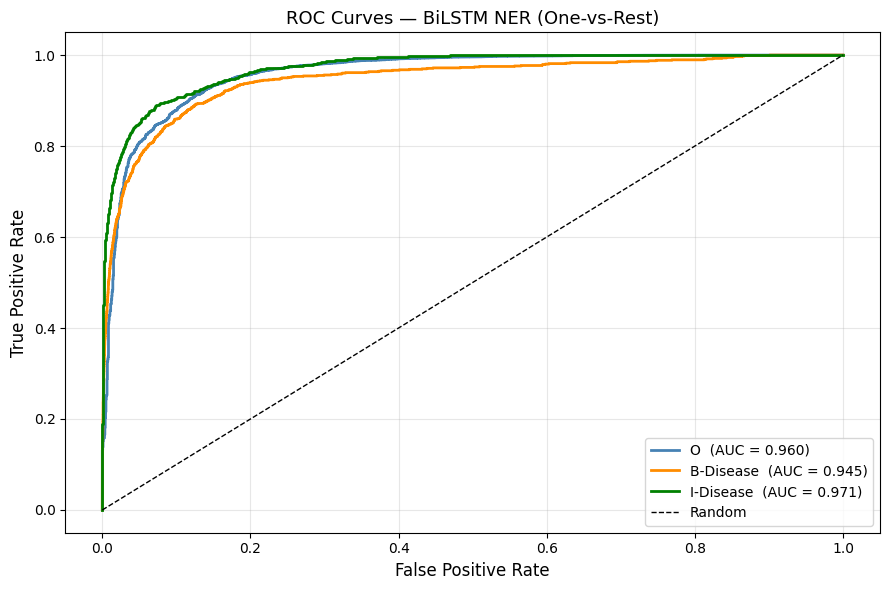

In [ ]:
# ── Figure 2: Precision & Recall per class ───────────────────────────────────
prec = precision_score(all_true_flat, flat_pred, average=None, labels=[0,1,2], zero_division=0)
rec  = recall_score(   all_true_flat, flat_pred, average=None, labels=[0,1,2], zero_division=0)

x, width = np.arange(3), 0.35
fig, ax  = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, prec, width, label='Precision', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, rec,  width, label='Recall',    color='darkorange', alpha=0.85)
for bar in [*bars1, *bars2]:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
            f'{h:.2f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel('Score', fontsize=12); ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Precision & Recall — BiLSTM NER', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('results/05_precision_recall.png', dpi=150)
plt.show()
print('Saved → results/05_precision_recall.png')

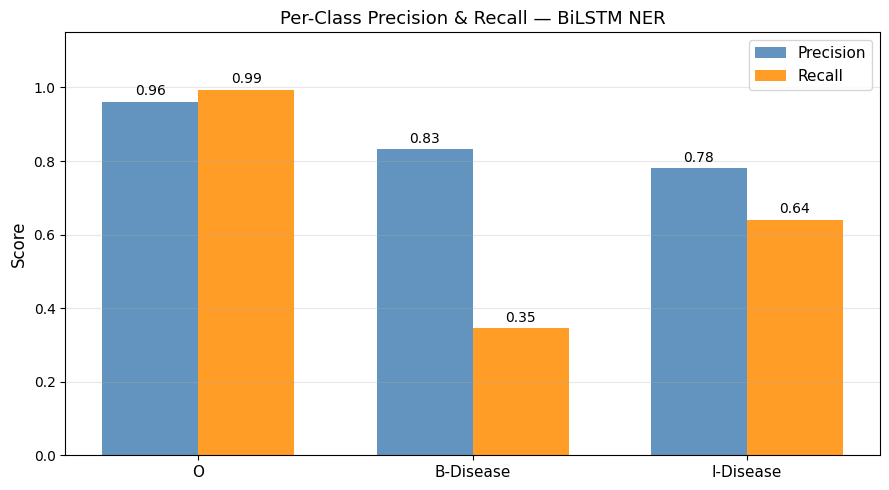

---
## Step 7 — 10 Example Predictions vs Ground Truth

In [ ]:
model.eval()
print('10 Example Predictions vs Ground Truth')
print('(Only sentences with at least one disease entity shown)\n')

shown = 0
for idx, row in df_test.iterrows():
    if shown >= 10:
        break

    tokens   = list(row['tokens'])
    ner_tags = list(row['ner_tags'])
    if len(tokens) == 0:
        continue

    # Prepare input tensor
    x = tokens_to_indices(tokens, word2idx, MAX_LENGTH)
    x_tensor = torch.tensor([x], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(x_tensor)           # (1, 128, 3)
        preds  = logits.argmax(dim=-1)[0]  # (128,)

    actual_len  = min(len(tokens), MAX_LENGTH)
    true_labels = [LABEL_MAP[t] for t in ner_tags[:actual_len]]
    pred_labels = [LABEL_MAP[preds[i].item()] for i in range(actual_len)]

    if len(true_labels) != len(pred_labels):
        continue

    # Only show sentences that have a disease entity
    if 'B-Disease' not in true_labels and 'B-Disease' not in pred_labels:
        continue

    print(f'--- Example {shown + 1}  (test sentence {idx}) ---')
    print(f'  {"Token":<25}  {"True":>12}  {"Pred":>12}')
    print(f'  {"-" * 52}')
    for tok, t, p in zip(tokens[:actual_len], true_labels, pred_labels):
        marker = '  <<<' if t != p else ''
        print(f'  {tok:<25}  {t:>12}  {p:>12}{marker}')
    print()
    shown += 1

---
## Step 8 — Training & Validation Loss Curve

In [ ]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, 'b-o', label='Train Loss', markersize=5, linewidth=1.5)
plt.plot(epochs_range, val_losses,   'r-o', label='Val Loss',   markersize=5, linewidth=1.5)
plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
            label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('BiLSTM NER — Training & Validation Loss', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs('results', exist_ok=True)
plt.savefig('results/bilstm_loss_curve.png', dpi=150)
plt.show()
print('Saved → results/bilstm_loss_curve.png')

---
## Step 9 — Save Results & Comparison Table

In [ ]:
results_path = 'results/ner_results.json'

new_result = {
    'method'   : 'bilstm',
    'precision': round(test_prec, 4),
    'recall'   : round(test_rec,  4),
    'f1'       : round(test_f1,   4)
}

# Load existing results
results_list = []
if os.path.exists(results_path):
    with open(results_path) as f:
        try:
            results_list = json.load(f)
        except json.JSONDecodeError:
            pass

# Update or append
updated = False
for r in results_list:
    if r.get('method') == 'bilstm':
        r.update(new_result)
        updated = True
        break
if not updated:
    results_list.append(new_result)

with open(results_path, 'w') as f:
    json.dump(results_list, f, indent=4)

print(f'Appended to {results_path}\n')

# ── Comparison table ──────────────────────────────────────────────────────────
METHOD_LABELS = {
    'rule_based': 'Rule-Based',
    'crf'       : 'CRF',
    'bilstm'    : 'BiLSTM'
}
ORDER = ['rule_based', 'crf', 'bilstm']

results_map = {r['method']: r for r in results_list}

print('=' * 58)
print(f'{"Method":<20}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}')
print('-' * 58)
for key in ORDER:
    if key not in results_map:
        continue
    r = results_map[key]
    label = METHOD_LABELS.get(key, key)
    print(f'{label:<20}  {r["precision"]:>10.4f}  {r["recall"]:>8.4f}  {r["f1"]:>8.4f}')
print('=' * 58)

rb  = results_map.get('rule_based')
crf = results_map.get('crf')
if rb:
    print(f'\nBiLSTM vs Rule-Based  Δ F1 = {new_result["f1"] - rb["f1"]:+.4f}')
if crf:
    print(f'BiLSTM vs CRF         Δ F1 = {new_result["f1"] - crf["f1"]:+.4f}')